In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Numerical Analysis

In [2]:
df = pd.read_csv('token_usage_log.csv')
print("Data Info:")
display(df.info())
print("\nData Description:")
display(df.describe())
print("\nFirst Few Rows:")
display(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               155 non-null    object 
 1   Step                    155 non-null    object 
 2   Input Tokens (Prompt)   155 non-null    int64  
 3   Output Tokens (Answer)  155 non-null    int64  
 4   Total Tokens            155 non-null    int64  
 5   Latency (s)             89 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 7.4+ KB


None


Data Description:


,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
count,155.000000,155.000000,155.000000,89.000000
mean,9542.870968,214.000000,10813.954839,5.900562
std,11310.991111,276.755553,13154.165282,5.072426
min,304.000000,3.000000,366.000000,0.910000
25%,738.000000,44.500000,885.500000,2.550000
50%,1181.000000,104.000000,1967.000000,4.660000
75%,22872.000000,286.500000,23457.500000,7.740000
max,27433.000000,1526.000000,46895.000000,26.620000



First Few Rows:


,Timestamp,Step,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
0,2026-04-19 16:44:36,Router_FRB,668,14,682,NaN
1,2026-04-19 16:44:39,Generator_FRB,486,205,691,NaN
2,2026-04-19 16:46:11,Router_FRB,661,25,686,NaN
3,2026-04-19 16:46:14,Generator_FRB,1240,100,1340,NaN
4,2026-04-19 17:03:17,Generator_FRB,455,268,723,NaN


In [3]:
df = df.rename(columns={
    'Input Tokens (Prompt)': 'Input Tokens',
    'Output Tokens (Answer)': 'Output Tokens',
    'Latency (s)': 'Latency'
})

df['Extra Tokens'] = df['Total Tokens'] - df['Input Tokens'] - df['Output Tokens']
df['Model'] = df['Step'].apply(lambda x: 'Naive' if '_Naive' in x else 'FRB' if '_FRB' in x else 'HRB')

df.head()

,Timestamp,Step,Input Tokens,Output Tokens,Total Tokens,Latency,Extra Tokens,Model
0,2026-04-19 16:44:36,Router_FRB,668,14,682,NaN,0,FRB
1,2026-04-19 16:44:39,Generator_FRB,486,205,691,NaN,0,FRB
2,2026-04-19 16:46:11,Router_FRB,661,25,686,NaN,0,FRB
3,2026-04-19 16:46:14,Generator_FRB,1240,100,1340,NaN,0,FRB
4,2026-04-19 17:03:17,Generator_FRB,455,268,723,NaN,0,FRB


In [4]:
step_token_usage_df = df.groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].mean().reset_index() 
display(step_token_usage_df)
step_time_usage_df = df.groupby(['Step', 'Model'])['Latency'].mean().reset_index()
display(step_time_usage_df)

model_token_usage_df = step_token_usage_df.groupby('Model')[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].sum().reset_index()
display(model_token_usage_df)
model_time_usage_df = step_time_usage_df.groupby('Model')['Latency'].sum().reset_index()
display(model_time_usage_df)

,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,Evaluator_FRB,FRB,1014.333333,110.888889,0.000000,1125.222222
1,Evaluator_HRB,HRB,1517.000000,71.363636,0.000000,1588.363636
2,Evaluator_Naive,Naive,26930.166667,60.250000,0.000000,26990.416667
3,Generator_FRB,FRB,669.794118,240.500000,311.411765,1221.705882
4,Generator_HRB,HRB,983.181818,723.363636,346.636364,2053.181818
5,Generator_Naive,Naive,24486.400000,355.500000,3690.725000,28532.625000
6,Router_FRB,FRB,824.035714,8.428571,64.571429,897.035714
7,Router_HRB,HRB,9405.000000,7.400000,1.000000,9413.400000


,Step,Model,Latency
0,Evaluator_FRB,FRB,2.630000
1,Evaluator_HRB,HRB,6.020000
2,Evaluator_Naive,Naive,8.830833
3,Generator_FRB,FRB,4.996667
4,Generator_HRB,HRB,6.989091
5,Generator_Naive,Naive,6.950000
6,Router_FRB,FRB,2.090000
7,Router_HRB,HRB,6.407000


,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,FRB,2508.163165,359.817460,375.983193,3243.963819
1,HRB,11905.181818,802.127273,347.636364,13054.945455
2,Naive,51416.566667,415.750000,3690.725000,55523.041667


,Model,Latency
0,FRB,9.716667
1,HRB,19.416091
2,Naive,15.780833


## Plots

### Cmap

In [5]:
# Colormap for each Step category

FRB = "#1F77B4"
HRB = "#328F3A"
full_db = "#f93e3e"

step_cmap = {
    'Router_FRB': FRB,
    'Generator_FRB': FRB,
    'Evaluator_FRB': FRB,

    'Router_HRB': HRB,
    'Generator_HRB': HRB,
    'Evaluator_HRB': HRB,

    'Generator_Naive': full_db,
    'Evaluator_Naive': full_db
}

model_cmap = {
    'FRB': FRB,
    'HRB': HRB,
    'Naive': full_db
}

### Comparison

#### Average token per model

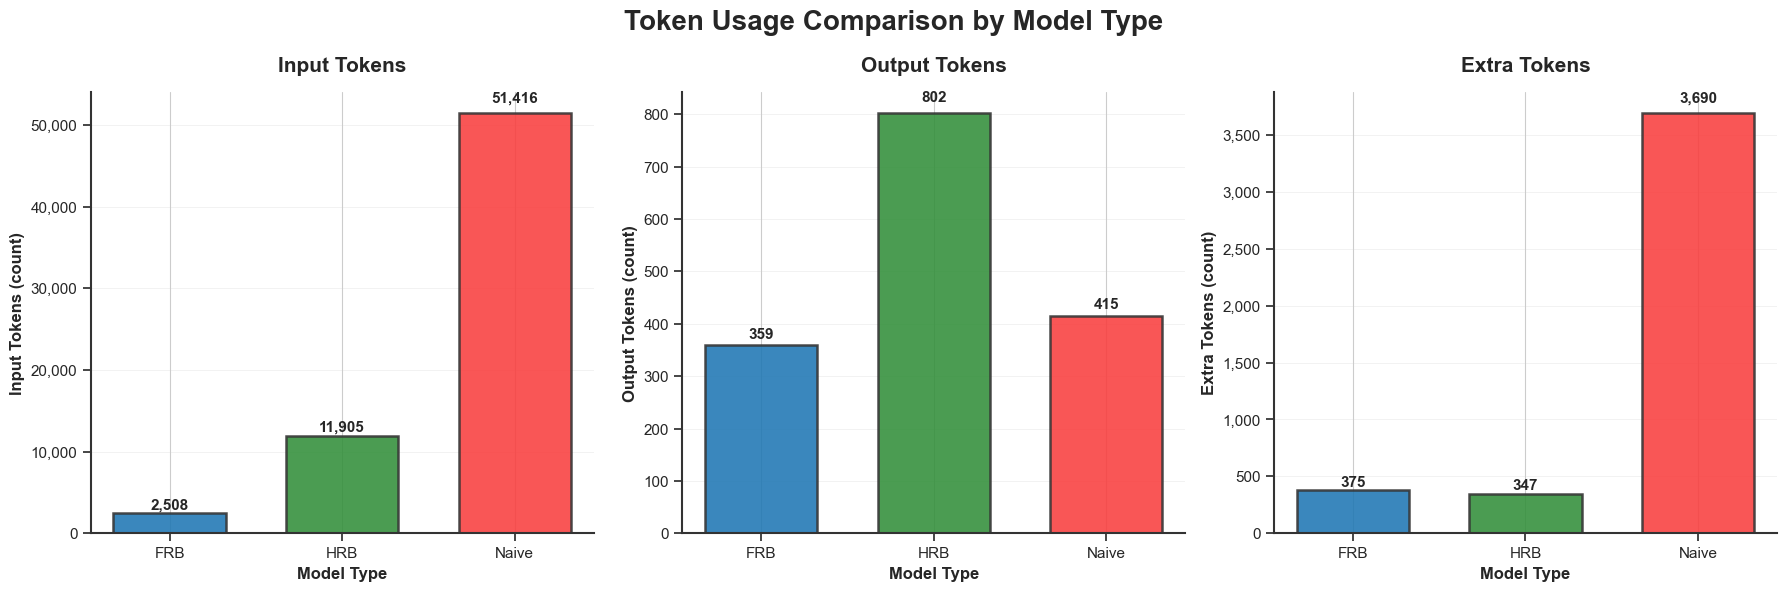

In [6]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    
    bars = ax.bar(model_token_usage_df['Model'], model_token_usage_df[metric], 
                   color=[model_cmap[model] for model in model_token_usage_df['Model']],
                   edgecolor='#333333', linewidth=1.8, alpha=0.88, width=0.65)
    
    ax.set_title(f'{metric}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel(f'{metric} (count)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Improve tick labels
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)
    ax.tick_params(axis='y', which='minor', labelsize=10)
    
    # Format y-axis with thousand separators
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Add value labels on bars with better formatting
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.02,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

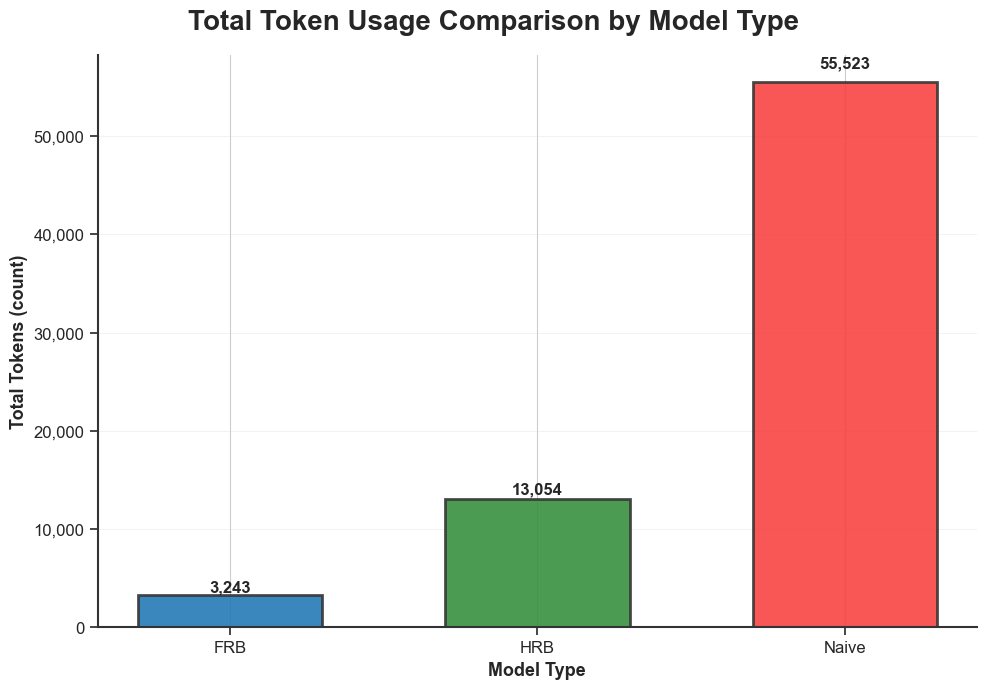

In [7]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_token_usage_df['Model'],
    model_token_usage_df['Total Tokens'],
    color=[model_cmap[model] for model in model_token_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Tokens (count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

# Format y-axis with thousand separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        #family='serif'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

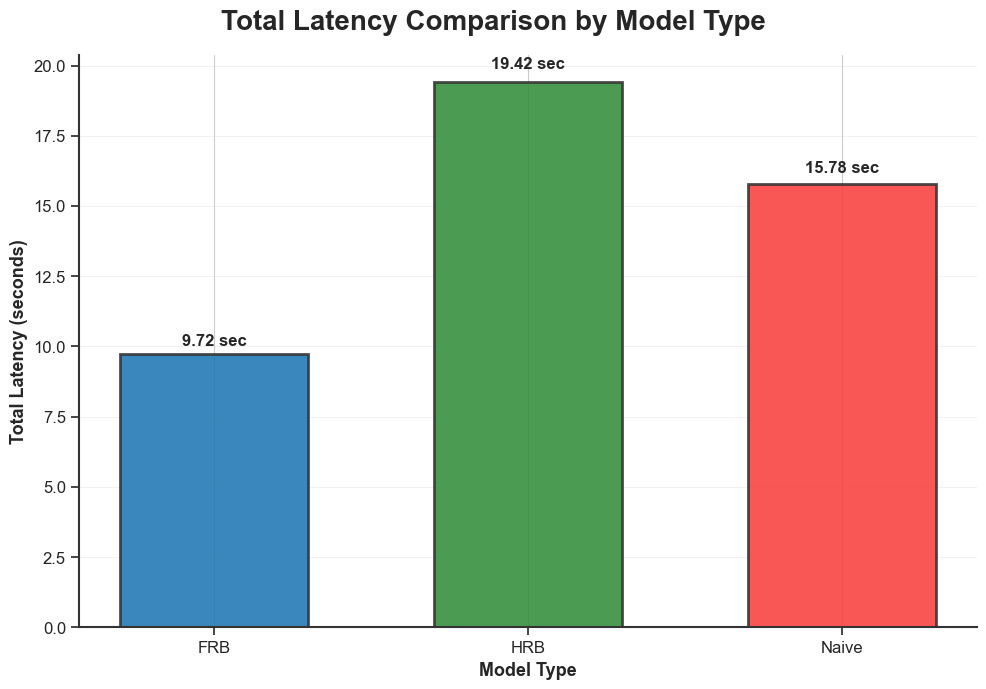

In [8]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Latency Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_time_usage_df['Model'],
    model_time_usage_df['Latency'],
    color=[model_cmap[model] for model in model_time_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Latency (seconds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{height:.2f} sec',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()